# Customer Churn Prediction — Logistic Regression, Decision Tree & Random Forest
### PRT565 — Machine Learning, Artificial Intelligence and Algorithms — Assessment 2 (ECP_2026_S2)

**Name:** Md Adnan Abir  
**Student ID:** s382198

## 1. Importing the required libraries

In [1]:
# data handling
import pandas as pd
import numpy as np

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#  preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#  the models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

#  evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

import warnings; warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("Libraries imported.")

Libraries imported.


## 2. Loading the dataset
**Data source: https://www.kaggle.com/datasets/rhonarosecortez/telco-customer-churn

In [2]:
# Loading dataset

import os

if not os.path.exists("TelcoCustomerChurn.csv"):
    try:
        from google.colab import files
        print("Please upload TelcoCustomerChurn.csv ...")
        uploaded = files.upload()
    except ModuleNotFoundError:
        print("Place TelcoCustomerChurn.csv in the same folder as this notebook.")

df = pd.read_csv("TelcoCustomerChurn.csv")
df.columns = [c.strip().replace('\ufeff', '') for c in df.columns]

print("Total Records:", len(df))
print("Shape (rows, columns):", df.shape)
df.head(10)

Please upload TelcoCustomerChurn.csv ...


Saving TelcoCustomerChurn.csv to TelcoCustomerChurn.csv
Total Records: 7043
Shape (rows, columns): (7043, 50)


,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges
5,4412-YLTKF,Female,72,No,Yes,No,Yes,1,United States,California,...,10,89.91,2235.41,1,Churned,Yes,95,4638,Competitor,Competitor had better devices
6,0390-DCFDQ,Female,76,No,Yes,Yes,Yes,2,United States,California,...,0,15.28,85.73,2,Churned,Yes,76,3964,Other,Don't know
7,3445-HXXGF,Male,66,No,Yes,Yes,No,0,United States,California,...,0,0.00,2610.25,1,Churned,Yes,91,5444,Dissatisfaction,Service dissatisfaction
8,2656-FMOKZ,Female,70,No,Yes,No,Yes,2,United States,California,...,0,661.05,1806.75,2,Churned,Yes,91,5717,Dissatisfaction,Limited range of services
9,2070-FNEXE,Female,77,No,Yes,No,Yes,2,United States,California,...,0,188.65,681.20,2,Churned,Yes,81,4419,Price,Lack of affordable download/upload speed


## 3. Analysing and describing the data

In [3]:
# Column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7043 non-null   object 
 1   Gender                         7043 non-null   object 
 2   Age                            7043 non-null   int64  
 3   Under30                        7043 non-null   object 
 4   SeniorCitizen                  7043 non-null   object 
 5   Married                        7043 non-null   object 
 6   Dependents                     7043 non-null   object 
 7   NumberofDependents             7043 non-null   int64  
 8   Country                        7043 non-null   object 
 9   State                          7043 non-null   object 
 10  City                           7043 non-null   object 
 11  ZipCode                        7043 non-null   int64  
 12  Latitude                       7043 non-null   f

In [4]:
# Summary statistics for the numeric columns
df.describe()

,Age,NumberofDependents,ZipCode,Latitude,Longitude,Population,Number_of_Referrals,TenureinMonths,AvgMonthlyLongDistanceCharges,AvgMonthlyGBDownload,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,ChurnScore,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [5]:
# Summary statistics for the categorical column
df.describe(include="object")

,CustomerID,Gender,Under30,SeniorCitizen,Married,Dependents,Country,State,City,Quarter,...,StreamingMovies,StreamingMusic,UnlimitedData,Contract,PaperlessBilling,PaymentMethod,CustomerStatus,ChurnLabel,ChurnCategory,ChurnReason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,1869,1869
unique,7043,2,2,2,2,2,1,1,1106,1,...,2,2,2,3,2,3,3,2,5,20
top,3186-AJIEK,Male,No,No,No,No,United States,California,Los Angeles,Q3,...,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Stayed,No,Competitor,Competitor had better devices
freq,1,3555,5642,5901,3641,5416,7043,7043,293,7043,...,4311,4555,4745,3610,4171,3909,4720,5174,841,313


In [6]:
# Find how many null / missing values are present in each column
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Under30,0
SeniorCitizen,0
Married,0
Dependents,0
NumberofDependents,0
Country,0
State,0


In [7]:
# Percentage of missing value of the dataset
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct[missing_pct > 0].sort_values(ascending=False)

,0
ChurnReason,73.46
ChurnCategory,73.46
Offer,55.05
InternetType,21.67


ChurnLabel
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.5%


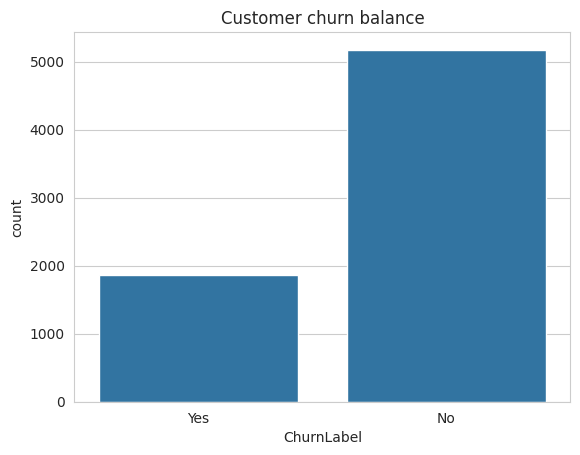

In [8]:
# how many customers churned (Yes) vs stayed (No)
print(df["ChurnLabel"].value_counts())
print("Churn rate: %.1f%%" % (100 * (df["ChurnLabel"] == "Yes").mean()))

sns.countplot(x="ChurnLabel", data=df)
plt.title("Customer churn balance")
plt.show()

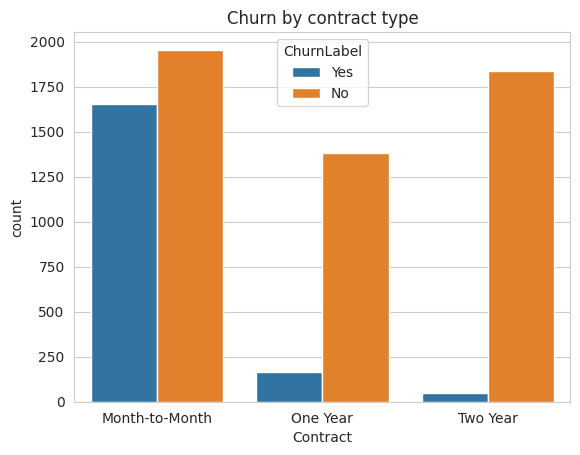

In [9]:
# Exploring how churn relates to the contract type
sns.countplot(x="Contract", hue="ChurnLabel", data=df)
plt.title("Churn by contract type")
plt.show()

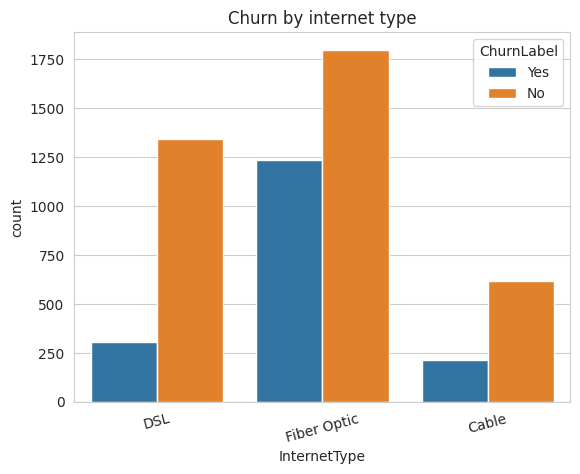

In [10]:
# Explore how churn relates to the type of internet connection
sns.countplot(x="InternetType", hue="ChurnLabel", data=df)
plt.title("Churn by internet type")
plt.xticks(rotation=15)
plt.show()

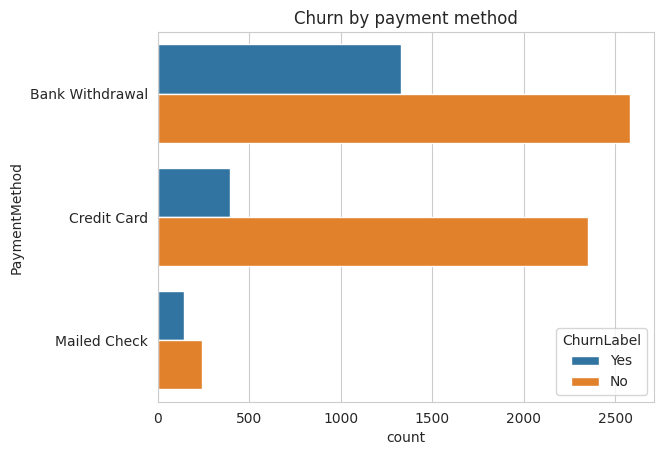

In [11]:
# Explore how churn relates to the customer's payment method
sns.countplot(y="PaymentMethod", hue="ChurnLabel", data=df)
plt.title("Churn by payment method")
plt.show()

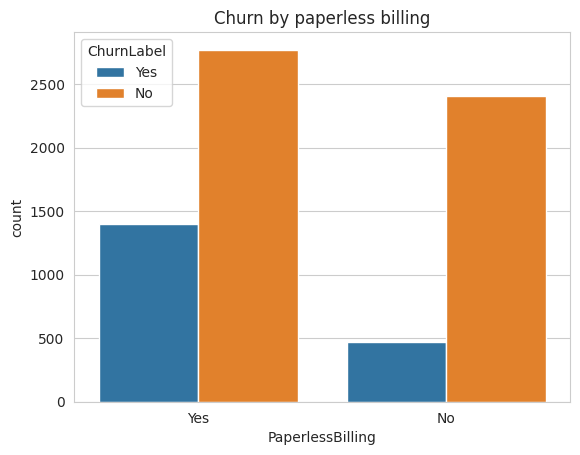

In [12]:
# Explore how churn relates to whether the customer uses paperless billing
sns.countplot(x="PaperlessBilling", hue="ChurnLabel", data=df)
plt.title("Churn by paperless billing")
plt.show()

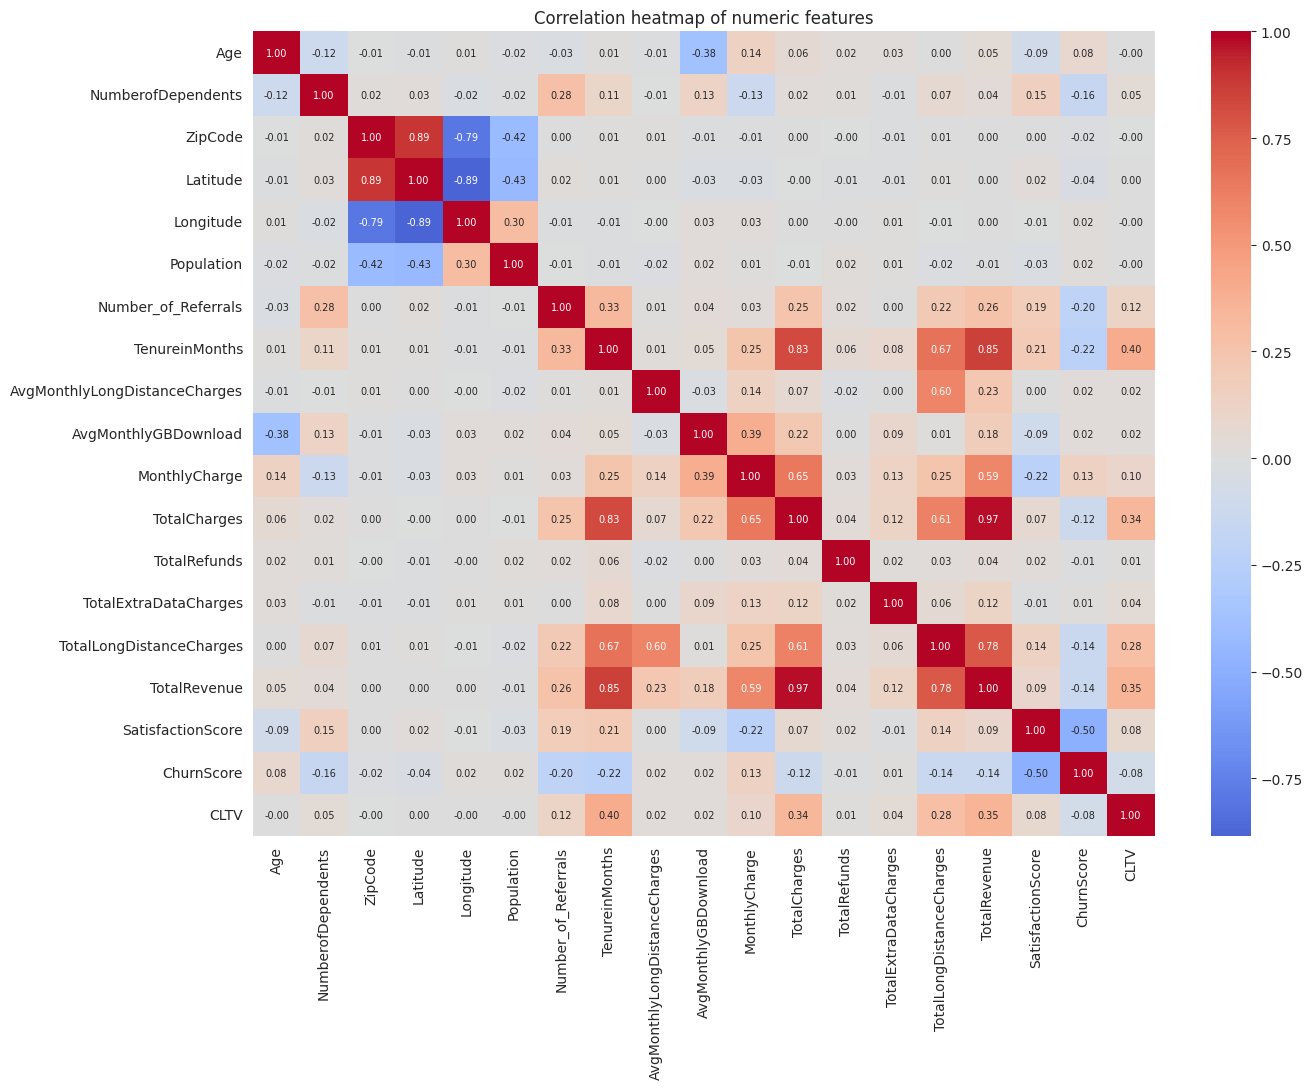

In [13]:
# Correlation between the numeric features
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(14, 11))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0, annot=True,
           fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation heatmap of numeric features")
plt.tight_layout()
plt.show()

## 4. Data preprocessing and cleaning

### 4.1 Remove leakage and identifier columns

In [14]:
leakage    = ["ChurnScore","ChurnCategory","ChurnReason",
              "CustomerStatus","SatisfactionScore","CLTV"]
identifier = ["CustomerID","Country","State","City","Quarter",
              "ZipCode","Latitude","Longitude","Population"]
df.drop(columns=leakage + identifier, inplace=True)
print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (7043, 35)


In [15]:
# Confirming none of the dropped columns remain,
dropped = set(leakage + identifier)
print("Any leakage/identifier columns remaining?", dropped & set(df.columns))
print("Remaining columns:", df.shape[1])

Any leakage/identifier columns remaining? set()
Remaining columns: 35


### 4.2 Impute missing categorical values

In [16]:
for col in ["Offer", "InternetType"]:
    imputer = SimpleImputer(strategy="constant", fill_value="None")
    df[[col]] = imputer.fit_transform(df[[col]])

print("Total missing values remaining:", int(df.isnull().sum().sum()))

Total missing values remaining: 0


### 4.3 Bin a numeric feature into categories

In [17]:
def tenure_group(months):
    if   months <= 12: return 0
    elif months <= 24: return 1
    elif months <= 48: return 2
    else:              return 3

df["TenureGroup"] = df["TenureinMonths"].apply(tenure_group)
df.drop(columns=["TenureinMonths"], inplace=True)
df["TenureGroup"].value_counts()

,count
TenureGroup,
3,2239
0,2186
2,1594
1,1024


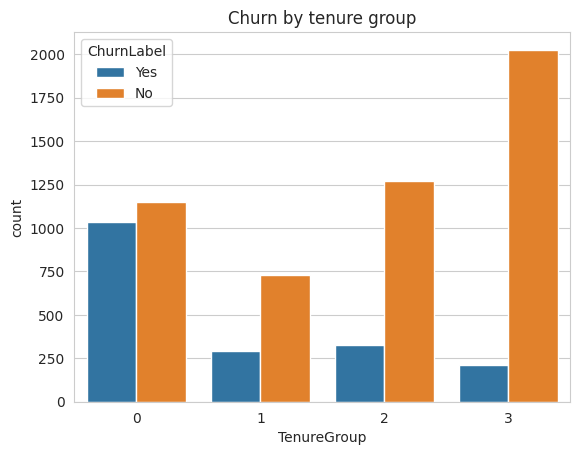

In [18]:
# Visualise churn rate across the new TenureGroup bands
sns.countplot(x="TenureGroup", hue="ChurnLabel", data=df)
plt.title("Churn by tenure group")
plt.show()

### 4.4 Encode categorical data

In [19]:
# Encode the target: Yes-> 1, No-> 0
df["ChurnLabel"] = df["ChurnLabel"].map({"Yes": 1, "No": 0})

# Encode gender and all the Yes/No service columns to 1/0
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
yesno = ["Under30","SeniorCitizen","Married","Dependents","ReferredaFriend","PhoneService",
         "MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtectionPlan",
         "PremiumTechSupport","StreamingTV","StreamingMovies","StreamingMusic","UnlimitedData",
         "PaperlessBilling"]
for col in yesno:
    df[col] = df[col].map({"Yes": 1, "No": 0})

# Onehot encode the remaining multicategory columns
df = pd.get_dummies(df, columns=["Offer","InternetType","Contract","PaymentMethod"],
                    drop_first=True)

print("Feature matrix after encoding:", df.shape)
df.head()

Feature matrix after encoding: (7043, 43)


,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,ReferredaFriend,Number_of_Referrals,PhoneService,...,Offer_Offer C,Offer_Offer D,Offer_Offer E,InternetType_DSL,InternetType_Fiber Optic,InternetType_None,Contract_One Year,Contract_Two Year,PaymentMethod_Credit Card,PaymentMethod_Mailed Check
0,1,78,0,1,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,False,False
1,0,74,0,1,1,1,1,1,1,1,...,False,False,True,False,True,False,False,False,True,False
2,1,71,0,1,0,1,3,0,0,1,...,False,True,False,False,True,False,False,False,False,False
3,0,78,0,1,1,1,1,1,1,1,...,True,False,False,False,True,False,False,False,False,False
4,0,80,0,1,1,1,1,1,1,1,...,True,False,False,False,True,False,False,False,False,False


In [20]:
# Checking every column is now numeric
df.dtypes.value_counts()

,count
int64,25
bool,12
float64,6


### 4.5 Splitting the data, then scale the numeric columns
75% training and 25% testing

In [21]:
X = df.drop(columns=["ChurnLabel"])
y = df["ChurnLabel"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=9, stratify=y)

# scale the continuous numeric columns only
num_cols = ["Age","NumberofDependents","Number_of_Referrals","AvgMonthlyLongDistanceCharges",
            "AvgMonthlyGBDownload","MonthlyCharge","TotalCharges","TotalRefunds",
            "TotalExtraDataCharges","TotalLongDistanceCharges","TotalRevenue"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Training rows:", X_train.shape[0], " Testing rows:", X_test.shape[0])

Training rows: 5282  Testing rows: 1761


In [22]:
# Checking if the churn ratio
print("Churn rate - full data :", round(y.mean(), 3))
print("Churn rate - train set :", round(y_train.mean(), 3))
print("Churn rate - test set  :", round(y_test.mean(), 3))

Churn rate - full data : 0.265
Churn rate - train set : 0.265
Churn rate - test set  : 0.265


## 5. Build and evaluate the three models

In [23]:
def evaluate(name, model):
    model.fit(X_train, y_train)               # tarin based on the training set
    y_pred = model.predict(X_test)            # Predict based on the unseen test set
    print(name)
    print("  Accuracy : %.4f" % accuracy_score(y_test, y_pred))
    print("  Precision: %.4f" % precision_score(y_test, y_pred))
    print("  Recall   : %.4f" % recall_score(y_test, y_pred))
    print("  F1 score : %.4f" % f1_score(y_test, y_pred))
    return model, y_pred

In [24]:
from sklearn.metrics import classification_report
all_results = {}

def evaluate_full(name, model):
    model, y_pred = evaluate(name, model)
    print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))
    all_results[name] = {"model": model, "y_pred": y_pred}
    return model, y_pred

### 5.1 Logistic Regression

Logistic Regression
  Accuracy : 0.8455
  Precision: 0.7372
  Recall   : 0.6488
  F1 score : 0.6902
              precision    recall  f1-score   support

    No churn       0.88      0.92      0.90      1294
       Churn       0.74      0.65      0.69       467

    accuracy                           0.85      1761
   macro avg       0.81      0.78      0.79      1761
weighted avg       0.84      0.85      0.84      1761



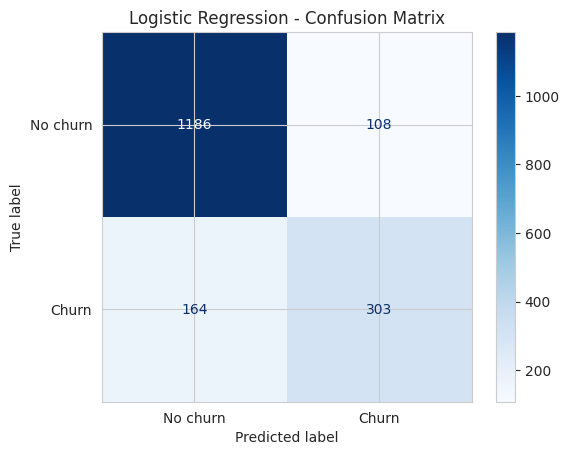

In [25]:
logreg, y_pred_lr = evaluate_full("Logistic Regression", LogisticRegression(max_iter=3000))

# Confusion matrix for the Logistic Regression model
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=["No churn","Churn"]).plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### 5.2 Decision Tree

Decision Tree
  Accuracy : 0.7939
  Precision: 0.8562
  Recall   : 0.2677
  F1 score : 0.4078
              precision    recall  f1-score   support

    No churn       0.79      0.98      0.88      1294
       Churn       0.86      0.27      0.41       467

    accuracy                           0.79      1761
   macro avg       0.82      0.63      0.64      1761
weighted avg       0.81      0.79      0.75      1761



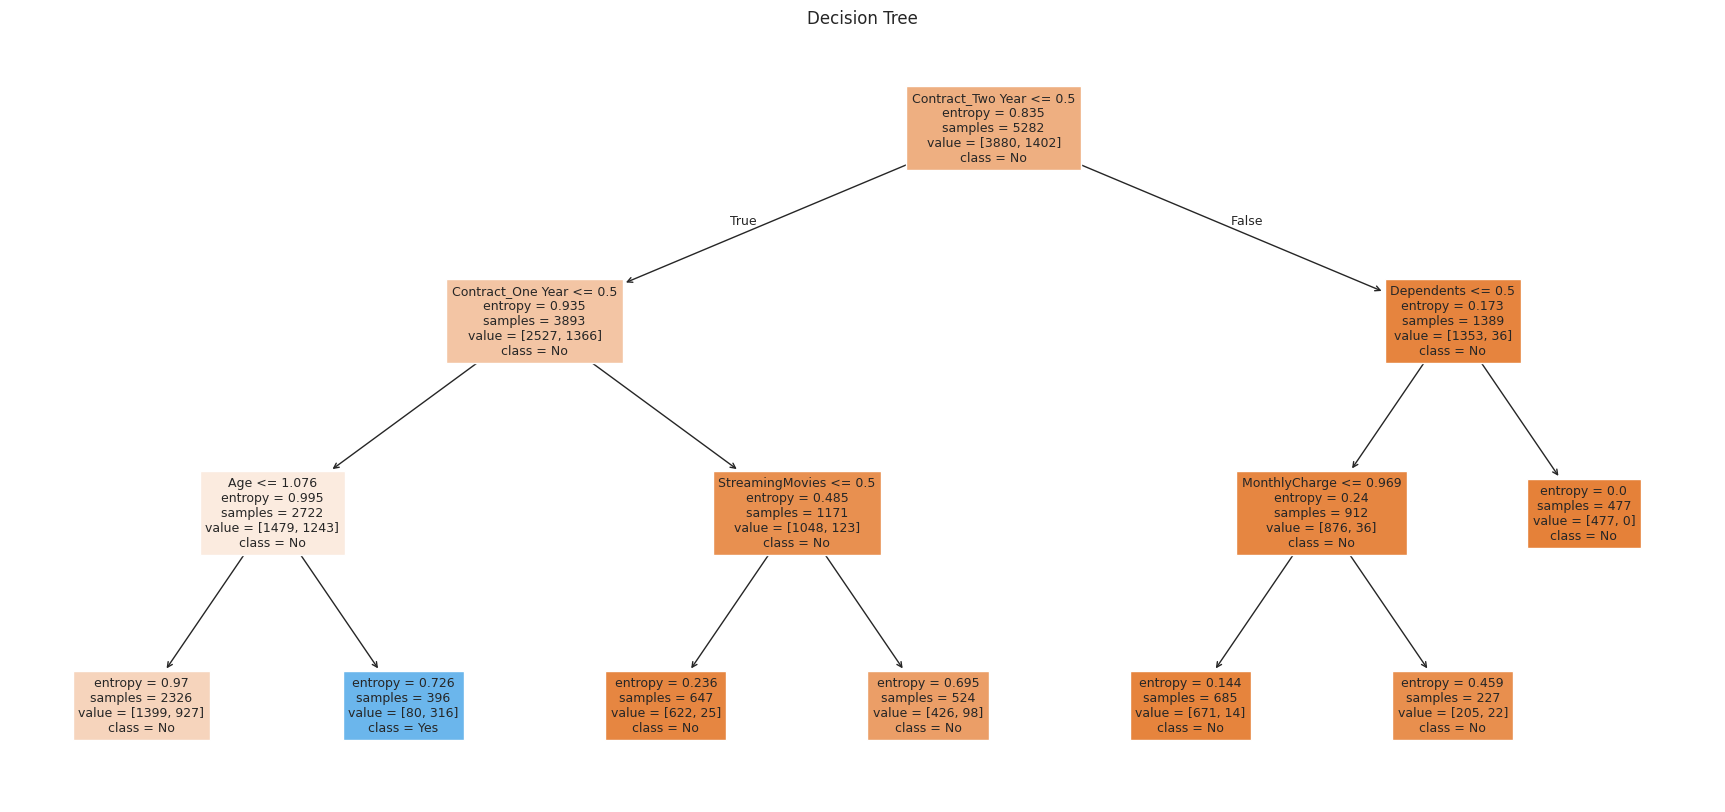

In [26]:
dtree, _ = evaluate_full("Decision Tree",
                    DecisionTreeClassifier(max_depth=3, criterion="entropy", random_state=9))

plt.figure(figsize=(22, 10))
plot_tree(dtree, feature_names=X.columns, class_names=["No", "Yes"],
          filled=True, fontsize=9)
plt.title("Decision Tree")
plt.show()

### 5.2.1 Effect of tree depth


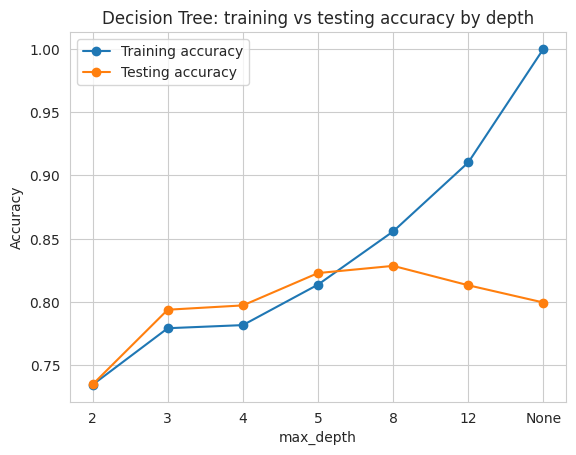

In [27]:
# Compare training vs testing accuracy across a range of tree depths
depths = [2, 3, 4, 5, 8, 12, None]
train_acc, test_acc = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, criterion="entropy", random_state=9)
    t.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, t.predict(X_train)))
    test_acc.append(accuracy_score(y_test, t.predict(X_test)))

depth_labels = [str(d) for d in depths]
plt.plot(depth_labels, train_acc, marker="o", label="Training accuracy")
plt.plot(depth_labels, test_acc, marker="o", label="Testing accuracy")
plt.xlabel("max_depth"); plt.ylabel("Accuracy"); plt.legend()
plt.title("Decision Tree: training vs testing accuracy by depth")
plt.show()

### 5.3 Random Forest

Random Forest
  Accuracy : 0.8455
  Precision: 0.7910
  Recall   : 0.5675
  F1 score : 0.6608
              precision    recall  f1-score   support

    No churn       0.86      0.95      0.90      1294
       Churn       0.79      0.57      0.66       467

    accuracy                           0.85      1761
   macro avg       0.82      0.76      0.78      1761
weighted avg       0.84      0.85      0.84      1761



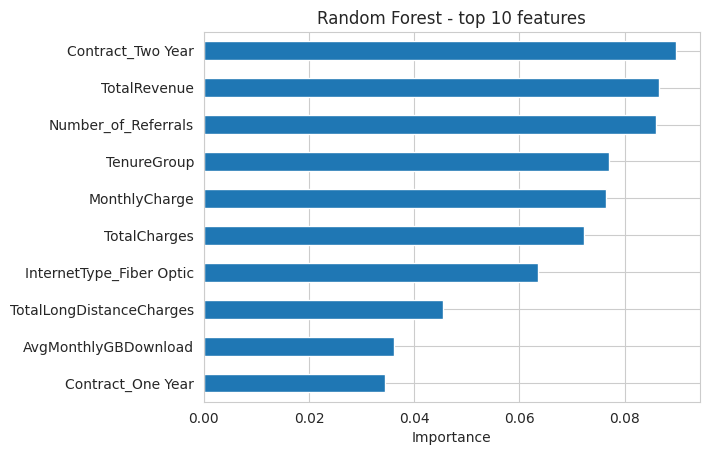

In [28]:
rforest, _ = evaluate_full("Random Forest",
                     RandomForestClassifier(n_estimators=100, max_depth=8, random_state=9))
importances = pd.Series(rforest.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind="barh")
plt.title("Random Forest - top 10 features")
plt.xlabel("Importance")
plt.show()

## 6. Compare the three models

              Model  Accuracy
Logistic Regression  0.845542
      Decision Tree  0.793867
      Random Forest  0.845542


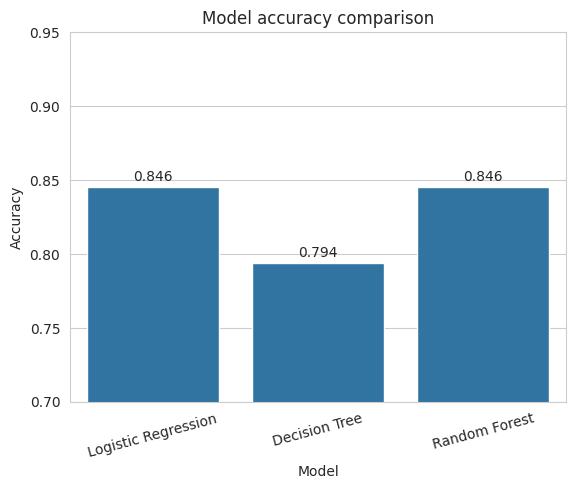

In [29]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy": [accuracy_score(y_test, logreg.predict(X_test)),
                 accuracy_score(y_test, dtree.predict(X_test)),
                 accuracy_score(y_test, rforest.predict(X_test))]
})
print(results.to_string(index=False))

ax = sns.barplot(x="Model", y="Accuracy", data=results)
plt.ylim(0.70, 0.95); plt.xticks(rotation=15); plt.title("Model accuracy comparison")
for i, v in enumerate(results["Accuracy"]):
    ax.text(i, v + 0.004, "%.3f" % v, ha="center")
plt.show()

              Model  F1 (churn)
Logistic Regression    0.690205
      Decision Tree    0.407830
      Random Forest    0.660848


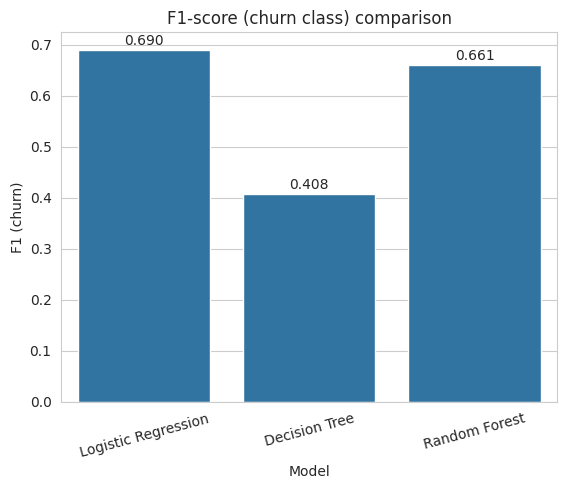

In [30]:
# Compare F1-score
f1_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "F1 (churn)": [f1_score(y_test, logreg.predict(X_test)),
                    f1_score(y_test, dtree.predict(X_test)),
                    f1_score(y_test, rforest.predict(X_test))]
})
print(f1_results.to_string(index=False))

ax = sns.barplot(x="Model", y="F1 (churn)", data=f1_results)
plt.xticks(rotation=15); plt.title("F1-score (churn class) comparison")
for i, v in enumerate(f1_results["F1 (churn)"]):
    ax.text(i, v + 0.01, "%.3f" % v, ha="center")
plt.show()

## 7. Further data analysis

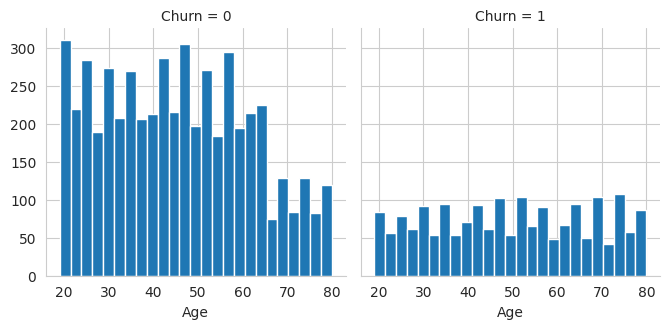

In [31]:
# Age distribution split by churn
g = sns.FacetGrid(df.assign(Churn=y), col="Churn", height=3.4)
g.map(plt.hist, "Age", bins=25)
g.set_titles("Churn = {col_name}")
plt.show()

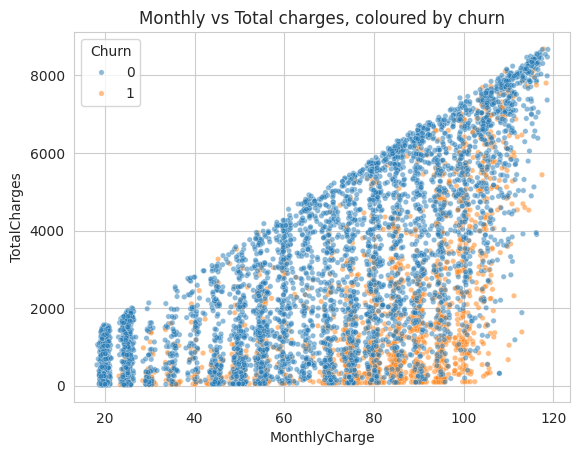

In [32]:
# Monthly vs Total charges, coloured by churn
sns.scatterplot(data=df.assign(Churn=y), x="MonthlyCharge", y="TotalCharges",
                hue="Churn", alpha=0.5, s=15)
plt.title("Monthly vs Total charges, coloured by churn")
plt.show()

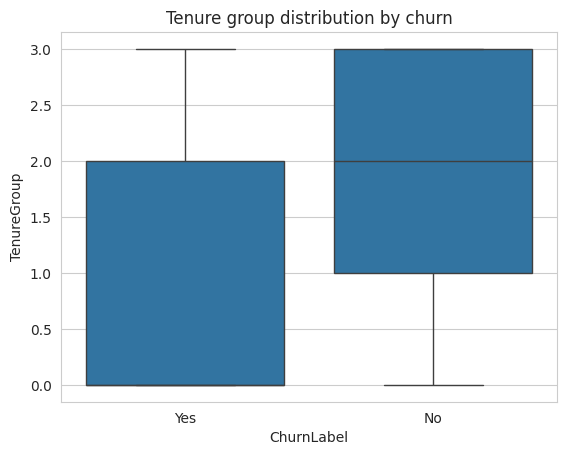

In [33]:
# Boxplot of tenure split by churn
sns.boxplot(x="ChurnLabel", y="TenureGroup", data=df.assign(ChurnLabel=y.map({0: "No", 1: "Yes"})))
plt.title("Tenure group distribution by churn")
plt.show()